In [1]:
import sys
import numpy as np
import pandas as pd
import sklearn
print ("Python version:", sys.version)
print ("NumPy version:", np.__version__)
print ("Pandas version:", pd.__version__)
print ("Scikit-learn version:", sklearn.__version__)

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
NumPy version: 2.3.5
Pandas version: 2.3.3
Scikit-learn version: 1.7.2


In [2]:
np.random.seed(42)
X = np.random.randn(100, 5)
print("\nДля всей матрицы:")
print("Среднее (mean):", X.mean())
print("Стандартное отклонение (std):", X.std())
print("Минимум (min):", X.min())
print("Максимум (max):", X.max())
print("\nДля каждого столбца:")
print("Среднее (mean):", X.mean(axis=0))
print("Стандартное отклонение (std):", X.std(axis=0))
print("Минимум (min):", X.min(axis=0))
print("Максимум (max):", X.max(axis=0))
w = np.array([0.5, 1.0, -0.5, 2.0, 1.5])
y = X @ w
print(y.mean())


Для всей матрицы:
Среднее (mean): 0.006837994588647575
Стандартное отклонение (std): 0.9802715029966268
Минимум (min): -3.2412673400690726
Максимум (max): 3.852731490654721

Для каждого столбца:
Среднее (mean): [-0.04474719  0.07695423 -0.09387351  0.12805847 -0.03220203]
Стандартное отклонение (std): [0.89583921 0.9791772  0.97901142 0.95474576 1.06742857]
Минимум (min): [-1.9520878  -2.30192116 -3.24126734 -1.91328024 -2.6197451 ]
Максимум (max): [2.31465857 1.8861859  2.1221562  3.07888081 3.85273149]
0.3093312863154943


In [3]:
df = pd.DataFrame(X, columns=['признак_1', 'признак_2', 'признак_3', 'признак_4', 'признак_5'])
df['target'] = y
print(df.head())
print("Размер таблицы (строки, столбцы):", df.shape)
print("Описательная статистика:\n", df.describe())
print("Количество пропусков в каждом столбце:")
print(df.isnull().sum())
df_filtered = df[df['target'] > 0]
print(f"Строк с target > 0: {len(df_filtered)}")
print(df_filtered.head())

   признак_1  признак_2  признак_3  признак_4  признак_5    target
0   0.496714  -0.138264   0.647689   1.523030  -0.234153  2.481078
1  -0.234137   1.579213   0.767435  -0.469474   0.542560  0.953318
2  -0.463418  -0.465730   0.241962  -1.913280  -1.724918 -7.232357
3  -0.562288  -1.012831   0.314247  -0.908024  -1.412304 -5.385602
4   1.465649  -0.225776   0.067528  -1.424748  -0.544383 -3.192786
Размер таблицы (строки, столбцы): (100, 6)
Описательная статистика:
         признак_1   признак_2   признак_3   признак_4   признак_5      target
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000
mean    -0.044747    0.076954   -0.093874    0.128058   -0.032202    0.309331
std      0.900352    0.984110    0.983943    0.959556    1.072806    2.719972
min     -1.952088   -2.301921   -3.241267   -1.913280   -2.619745   -7.232357
25%     -0.734897   -0.678136   -0.700307   -0.536288   -0.757046   -1.582398
50%     -0.010110    0.066421   -0.024662    0.152465   -0.14

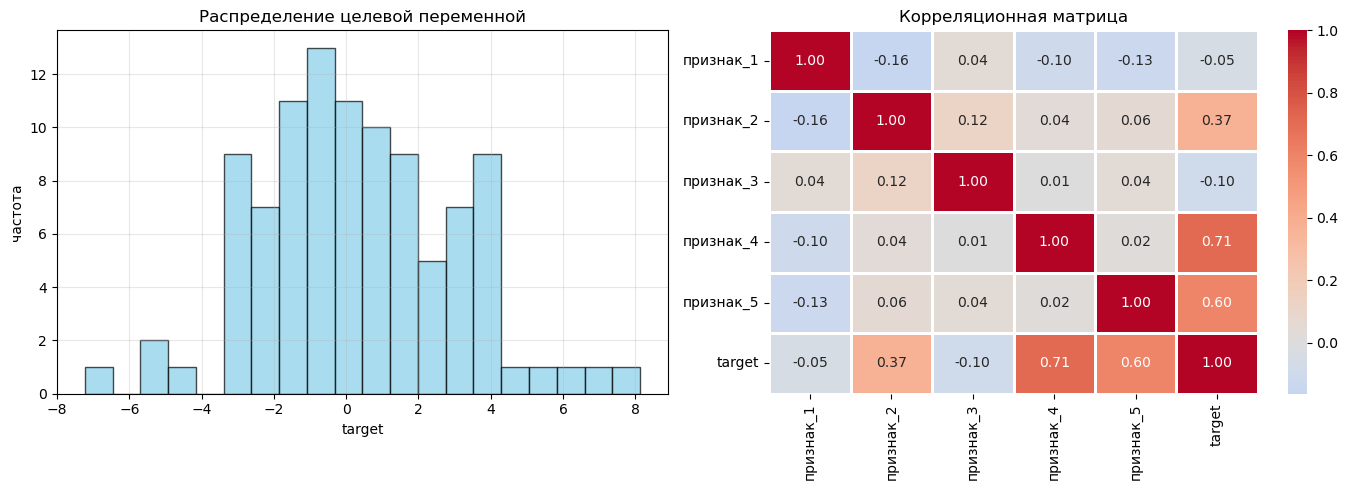

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df['target'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Распределение целевой переменной')
plt.xlabel('target')
plt.ylabel('частота')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
corr_matrix = df[['признак_1', 'признак_2', 'признак_3', 'признак_4', 'признак_5', 'target']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=1)
plt.title('Корреляционная матрица')

plt.tight_layout()
plt.show()